In [104]:
!wget https://www.dropbox.com/s/h160fwrthtb4gte/Base_Clientes_Monopoly.csv

--2025-04-23 03:28:37--  https://www.dropbox.com/s/h160fwrthtb4gte/Base_Clientes_Monopoly.csv
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/mz5u7ddatqayntt2crleq/Base_Clientes_Monopoly.csv?rlkey=nyn3hzxxby855id3gxxlbdev6 [following]
--2025-04-23 03:28:37--  https://www.dropbox.com/scl/fi/mz5u7ddatqayntt2crleq/Base_Clientes_Monopoly.csv?rlkey=nyn3hzxxby855id3gxxlbdev6
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb8fea28320797801d8824a8447.dl.dropboxusercontent.com/cd/0/inline/CoX_QftLXYnF9c1N_i2D7nOm70UvMUlb3WR9IxSkmlpOf_k52_WtUq6yEXXsmq1zj-T0-yM2CvuPcR25y5r5q90p1OrVtjxCE2PPpO9AYug57vlumNiJ2zRro8A1BmJMYuUrt4l11NYaMqD_H0H2Yp-0/file# [following]
--2025-04-23 03:28:38--  https://ucb8fea28320797801d8824a84

In [105]:
!pip install ydata-profiling

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [107]:
data = pd.read_csv("Base_Clientes_Monopoly.csv", sep=";", low_memory = False)
data.head()

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,ColMx_T01,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target
0,1,160,M,13.0,43,NaN,130,1,1,0,...,0,33000,0,1099866,0,1099866,15080,0,R,0
1,2,160,H,13.0,46,143640,69,1,0,0,...,0,300000,0,214592,0,214592,83596,0,R,0
2,3,170,H,13.0,45,929106,24,1,1,0,...,0,216676,0,0,0,7400,0,0,T,0
3,4,151,H,13.0,46,172447,134,0,1,0,...,0,60000,0,272762,0,272762,10591,0,R,0
4,5,170,H,13.0,46,805250,116,0,1,1,...,0,272925,0,249562,0,75339,377782,0,R,0


# Fase 1 - Comprensión del negocio

El objetivo del presente trabajo, será el análisis de la variable Renta, esto con la finalidad de detectar niveles socioeconómicos en relación a la edad y el sexo de las personas.

Primeramente se realizará una inspección de la existencia de nulos en la variable Renta, los cuales tendrán que ser manejados efectivamente. Para saber cómo se manejaran los datos nulos, se realizará un gráfico de caja, y si se presentan valores atípicos, se imputará por la mediana, en caso contrario con la media. Para imputar se utilizará KNNImputer.  

También se realizarán gráficos para un análisis visual.

Y por último, se realizará un escalamiento de los datos.

#Fase 2 - Comprensión de los datos

In [108]:
df = pd.DataFrame(data)

Primeramente realizamos un resumen de nuestras variables a utilizar. Donde podremos visualizar tablas y gráficos relacionados.

In [109]:
profile = ProfileReport(df[['Renta', 'Sexo', 'Edad']], title="Reporte personalizado", explorative=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 3/3 [00:01<00:00,  2.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Ahora se realiza un gráfico de caja, con el fin de visualizar datos atípicos y poder tomar mejores decisiones a la hora de manejar nuestros datos nulos.

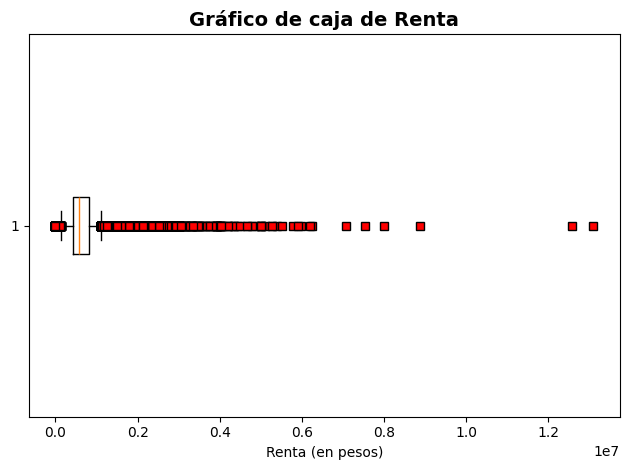

In [110]:
df['Renta'] = pd.to_numeric(df['Renta'], errors='coerce')

red_square = dict(markerfacecolor='r', marker='s')
fig2, ax2 = plt.subplots()

ax2.set_title('Gráfico de caja de Renta', fontsize=14, fontweight="bold")
ax2.boxplot(df['Renta'].dropna(), flierprops=red_square, vert=False, whis=0.75)

plt.xlabel("Renta (en pesos)")
plt.tight_layout()
plt.show()

In [111]:
df['Renta'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Renta
0.05,225141.6
0.25,419999.0
0.50,567000.0
0.75,814831.0
0.95,1311495.0


La tabla de arriba, en donde calculamos los percentiles, podemos apreciar que el 5% de la población tiene una renta menor a \$225.141. La mediana (percentil 50) es de \$567.000.

También se aprecia que el 5% superior tiene una renta de más de $1.311.495. Esto concuerda con nuestro gráfico de caja, que nos mostraba datos atípicos relacionados con ingresos altos.

A continuación se procede a usar KNNImport para el manejo de datos nulos.

In [112]:
datos_knn = data.copy()
datos_knn = pd.DataFrame(datos_knn)

datos_knn['Renta'] = datos_knn['Renta'].str.replace(',', '.').astype(float)

columnas_para_imputar = ['Renta', 'Edad']

datos_knn[columnas_para_imputar] = datos_knn[columnas_para_imputar].astype(str).replace(',', '.', regex=True).astype(float)

imputer = KNNImputer(n_neighbors=5, weights="uniform")

datos_knn[columnas_para_imputar] = imputer.fit_transform(datos_knn[columnas_para_imputar])

datos_knn

,Id,Subsegmento,Sexo,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,...,ColMx_T01,PagoNac_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoL2_T01,UsoLI_T01,IndRev_T01,target
0,1,160,M,13.0,43.0,879017.4,130,1,1,0,...,0,33000,0,1099866,0,1099866,15080,0,R,0
1,2,160,H,13.0,46.0,143640.0,69,1,0,0,...,0,300000,0,214592,0,214592,83596,0,R,0
2,3,170,H,13.0,45.0,929106.0,24,1,1,0,...,0,216676,0,0,0,7400,0,0,T,0
3,4,151,H,13.0,46.0,172447.0,134,0,1,0,...,0,60000,0,272762,0,272762,10591,0,R,0
4,5,170,H,13.0,46.0,805250.0,116,0,1,1,...,0,272925,0,249562,0,75339,377782,0,R,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,51120,160,H,13.0,51.0,364978.0,57,1,1,1,...,0,300000,0,478320,0,478320,12668,0,R,0
51120,51121,170,H,13.0,51.0,625376.0,39,1,0,0,...,0,166098,0,166098,0,0,572363,0,R,0
51121,51122,160,H,13.0,47.0,806220.0,153,1,1,0,...,0,18891,0,9652,0,9652,16241,0,R,0
51122,51123,160,M,13.0,47.0,597843.4,11,1,0,0,...,0,26528,0,24638,0,24638,84982,0,R,0


Ahora, agruparemos las edades y graficaremos al renta según los rangos de edad.

In [113]:
bins = [0, 18, 25, 35, 45, 55, 65, 75, 100, 120]
labels = ['0-17', '18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '75-99', '100-120']

binnedPopulation = pd.cut(datos_knn['Edad'], bins=bins, labels=labels, right=True)

<ipython-input-114-06a4b8123adc>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  renta_promedio_por_rango = datos_knn.groupby('Edad_rango')['Renta'].mean()


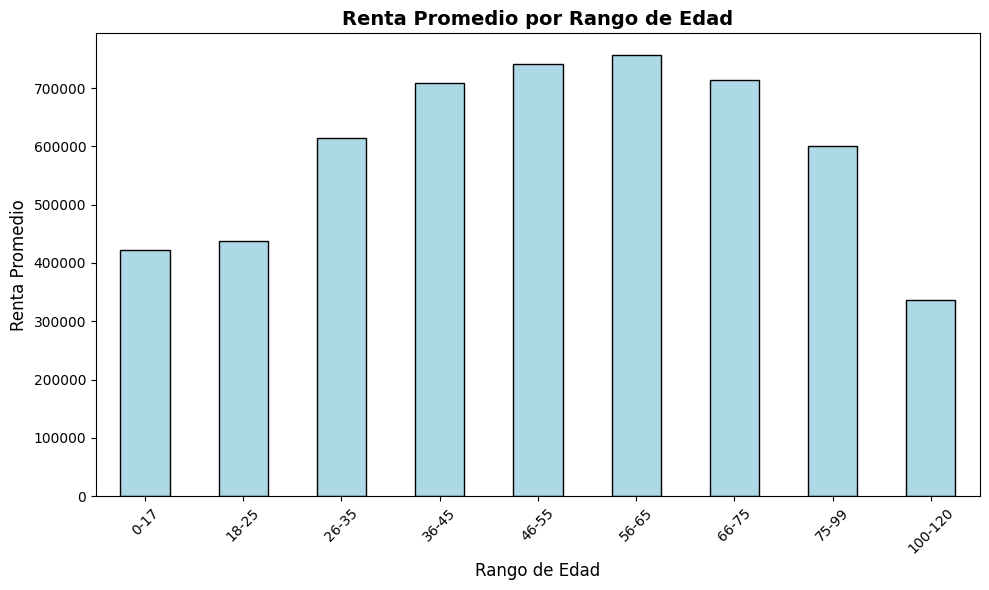

In [114]:
datos_knn['Edad_rango'] = binnedPopulation

renta_promedio_por_rango = datos_knn.groupby('Edad_rango')['Renta'].mean()

# Creación del gráfico
plt.figure(figsize=(10, 6))
renta_promedio_por_rango.plot(kind='bar', color='lightblue', edgecolor='black')

plt.title('Renta Promedio por Rango de Edad', fontsize=14, fontweight="bold")
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Renta Promedio', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Creamos un gráfico de caja para la renta de hombres y mujeres.

<ipython-input-115-901b29a141fd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sexo', y='Renta', data=datos_knn, palette='pastel')


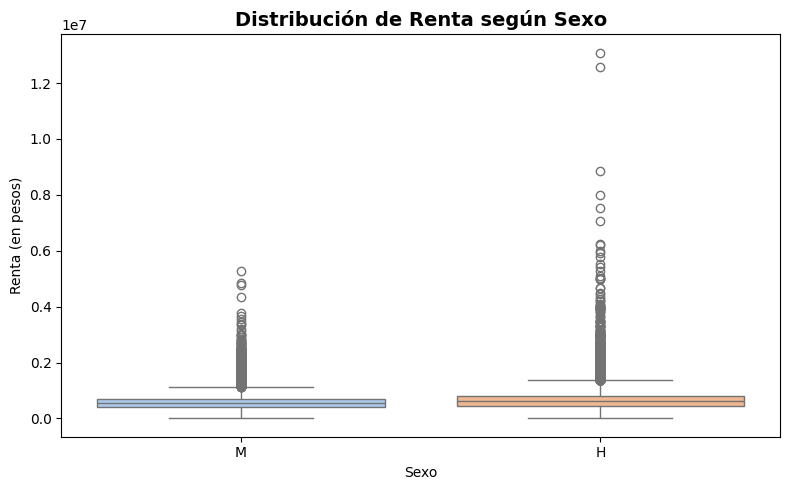

In [115]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sexo', y='Renta', data=datos_knn, palette='pastel')

plt.title('Distribución de Renta según Sexo', fontsize=14, fontweight="bold")
plt.xlabel('Sexo')
plt.ylabel('Renta (en pesos)')
plt.tight_layout()
plt.show()

En este gráfico se observa que la mediana de la renta es menor en el grupo de mujeres, lo que podría mostrar una desigualdad en los ingresos entre géneros.

Ahora procedemos a realizar un gráfico de barras para tener algo más visual.

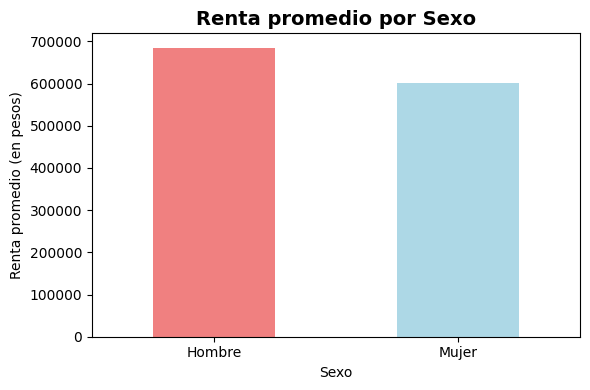

In [116]:
media_renta_por_sexo = datos_knn.groupby('Sexo')['Renta'].mean()

datos_knn['Sexo'] = datos_knn['Sexo'].map({'M': 'Mujer', 'H': 'Hombre'})

media_renta_por_sexo = datos_knn.groupby('Sexo')['Renta'].mean()

plt.figure(figsize=(6, 4))
media_renta_por_sexo.plot(kind='bar', color=['lightcoral', 'lightblue'])

plt.title('Renta promedio por Sexo', fontsize=14, fontweight="bold")
plt.xlabel('Sexo')
plt.ylabel('Renta promedio (en pesos)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#Fase 3 - Preparación de datos

Ahora se realiza un escalamiento con StandarScaler debido a que las variables Renta y Edad tienen rangos muy distintos, por lo que se realiza un escalamiento. Con esto logramos que no afecte a análisis posteriores.

In [117]:
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()

array_scaler = scaler.fit_transform(df[columnas_numericas])

df_scalado = pd.DataFrame(array_scaler, columns=columnas_numericas)

df_final = pd.concat([df_scalado, df.drop(columns=columnas_numericas)], axis=1)

df_final

,Id,Subsegmento,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,Monoproducto,...,IndRev_T02,Col_T01,ColL1TE_T01,ColMx_T01,PagoInt_T01,EeccNac_T01,EeccInt_T01,UsoL1_T01,UsoLI_T01,IndRev_T01
0,-1.732017,-0.752290,0.640139,0.323032,NaN,2.553917,0.679384,1.703963,-0.785122,-0.259607,...,R,1069735,1040339,0,0,1099866,0,1099866,0,R
1,-1.731949,-0.752290,0.640139,0.548555,-1.269306,0.843902,0.679384,-0.586867,-0.785122,-0.259607,...,R,211884,162939,0,0,214592,0,214592,0,R
2,-1.731881,-0.410717,0.640139,0.473381,0.650395,-0.417584,0.679384,1.703963,-0.785122,-0.259607,...,T,7400,0,0,0,0,0,7400,0,T
3,-1.731814,-1.059706,0.640139,0.548555,-1.198901,2.666049,-1.471922,1.703963,-0.785122,3.851970,...,R,262160,244048,0,0,272762,0,272762,0,R
4,-1.731746,-0.410717,0.640139,0.548555,0.347687,2.161455,-1.471922,1.703963,1.273688,-0.259607,...,T,306161,0,0,0,249562,0,75339,0,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51119,1.731746,-0.752290,0.640139,0.924426,-0.728350,0.507506,0.679384,1.703963,1.273688,-0.259607,...,R,463255,379646,0,0,478320,0,478320,0,R
51120,1.731814,-0.410717,0.640139,0.924426,-0.091930,0.002911,0.679384,-0.586867,-0.785122,-0.259607,...,R,728406,0,0,0,166098,0,0,0,R
51121,1.731881,-0.752290,0.640139,0.623729,0.350058,3.198677,0.679384,1.703963,-0.785122,-0.259607,...,R,24373,24,0,0,9652,0,9652,0,R
51122,1.731949,-0.752290,0.640139,0.623729,NaN,-0.782014,0.679384,-0.586867,-0.785122,-0.259607,...,R,52360,33,0,0,24638,0,24638,0,R


In [118]:
df_final.describe()

,Id,Subsegmento,Region,Edad,Renta,Antiguedad,Internauta,Adicional,Dualidad,Monoproducto,...,TxsDebCom_T01,FacDebAtm_T01,TxsDebAtm_T01,ColL1T0_T01,ColL2T0_T01,ColL2AC_T01,ColL2CC_T01,PagoNac_T01,UsoL2_T01,target
count,5.112400e+04,5.112400e+04,5.107100e+04,5.112400e+04,3.775300e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,...,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04,5.112400e+04
mean,2.668496e-17,-7.115990e-17,-4.090375e-17,1.778998e-17,4.516999e-17,-6.226491e-17,1.156348e-16,1.223061e-16,-5.281399e-17,-2.890871e-17,...,1.542724e-17,-2.293239e-17,4.781056e-17,7.227178e-18,-6.115304e-17,-2.807480e-17,-2.557309e-17,4.725462e-17,-2.612903e-17,-3.891557e-18
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000013e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,...,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.732017e+00,-1.059706e+00,-2.896898e+00,-2.232889e+00,-1.620363e+00,-9.221790e-01,-1.471922e+00,-5.868673e-01,-7.851215e-01,-2.596074e-01,...,-5.199113e-01,-6.327879e-01,-7.347259e-01,-3.892288e-01,-4.124494e-01,-1.606356e-01,-4.085102e-01,-5.125044e-01,-3.145106e-01,-3.144419e-01
25%,-8.660085e-01,-7.522900e-01,-5.388734e-01,-8.045800e-01,-5.938767e-01,-6.979147e-01,-1.471922e+00,-5.868673e-01,-7.851215e-01,-2.596074e-01,...,-5.199113e-01,-6.327879e-01,-7.347259e-01,-3.892288e-01,-4.124494e-01,-1.606356e-01,-4.085102e-01,-4.789528e-01,-3.145013e-01,-3.144419e-01
50%,0.000000e+00,-4.107169e-01,6.401390e-01,-2.783608e-01,-2.346022e-01,-3.895514e-01,6.793840e-01,-5.868673e-01,-7.851215e-01,-2.596074e-01,...,-5.199113e-01,-3.858624e-01,-3.470852e-01,-3.892288e-01,-3.308618e-01,-1.606356e-01,-4.085102e-01,-2.843434e-01,-2.459600e-01,-3.144419e-01
75%,8.660085e-01,9.555755e-01,6.401390e-01,5.485549e-01,3.711037e-01,4.234066e-01,6.793840e-01,1.703963e+00,1.273688e+00,-2.596074e-01,...,1.360004e-01,2.506569e-01,2.989827e-01,-2.561858e-02,5.278624e-02,-1.606356e-01,-1.349037e-02,1.048452e-01,-7.844566e-02,-3.144419e-01
max,1.732017e+00,2.653940e+01,6.401390e-01,4.908656e+00,3.037031e+01,7.992326e+00,6.793840e-01,1.703963e+00,1.273688e+00,3.851970e+00,...,1.653379e+01,2.131615e+01,1.593383e+01,4.113985e+01,4.774353e+01,2.773645e+01,2.649444e+01,5.785242e+01,2.693300e+01,3.180238e+00


Aquí visualizaremos los datos escalados.

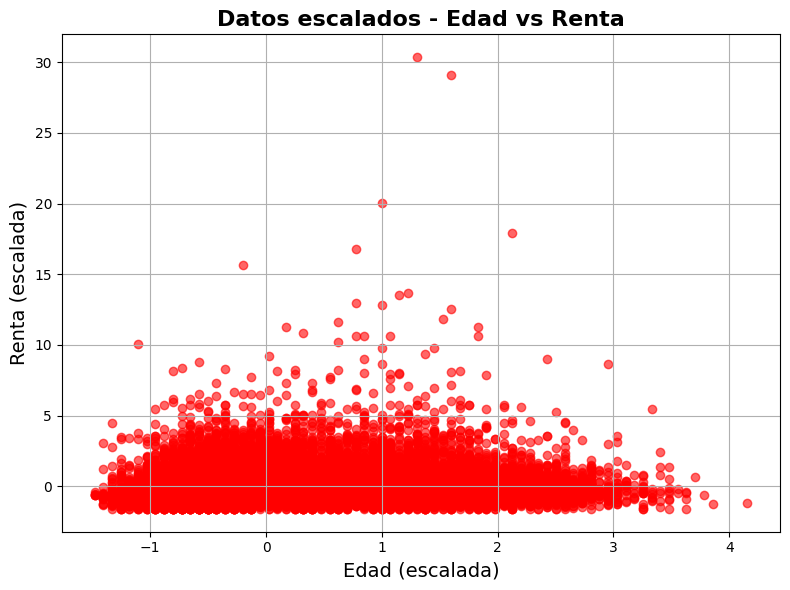

In [119]:
plt.figure(figsize=(8, 6))
plt.scatter(df_scalado['Edad'], df_scalado['Renta'], color='red', alpha=0.6)

plt.title('Datos escalados - Edad vs Renta', fontsize=16, fontweight="bold")
plt.xlabel('Edad (escalada)', fontsize=14)
plt.ylabel('Renta (escalada)', fontsize=14)
plt.grid()
plt.tight_layout()
plt.show()


Aquí se realiza una comparación entre los datos escalados y los no escalados.

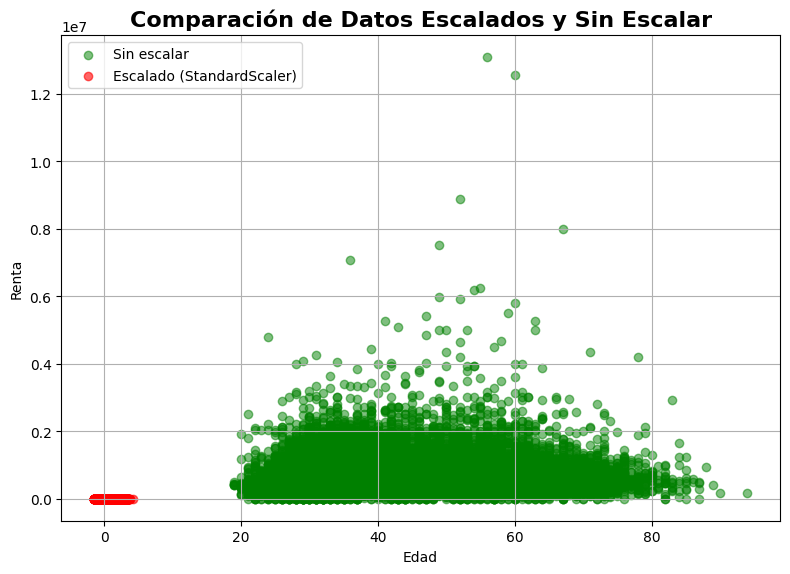

In [120]:
plt.figure(figsize=(8, 6))

plt.scatter(df['Edad'], df['Renta'], color='green', label='Sin escalar', alpha=0.5)

plt.scatter(df_scalado['Edad'], df_scalado['Renta'], color='red', label='Escalado (StandardScaler)', alpha=0.6)

plt.title('Comparación de Datos Escalados y Sin Escalar', fontsize=16, fontweight="bold")
plt.xlabel('Edad')
plt.ylabel('Renta')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()